# IE406 - Machine Learning: Lab-2
## Ridge Regression using Normal Equation and Polynomial Expansion

**Course Instructor:** Prof. Arunava Chakravarty  
**Teaching Assistants:** Hetul Kadiya, Kathan Shah  

---

### Objectives:
- Implement Ridge Regression using the **Normal Equation based closed-form solution** from scratch using **NumPy**.
- Perform **polynomial basis expansion** to project features into higher-dimensional space ($d \in \{1, 2, 3, 4\}$).
- Perform a **Grid Search** over polynomial degrees and $L_2$ regularization weights ($\lambda \in \{0.0001, 0.001, 0.01, 0.1, 1\}$).
- Visualize grid search validation performance using **heatmaps** (RMSE, MAPE, $R^2$).
- Select the best hyperparameter combination on validation set and evaluate on unseen **test set**.

### Setup and Environment Initialization

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

# Set random seed for full reproducibility
np.random.seed(9432)

# Global plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid")

---
## Task 1: Dataset Preparation

1. Load the **White Wine Quality** dataset (`winequality-white.csv`).
2. Randomly split dataset into **Training Set (60%)**, **Validation Set (20%)**, and **Test Set (20%)** using fixed seed `np.random.seed(9432)`.
3. Apply **Polynomial Basis Expansion** for degrees $d \in \{1, 2, 3, 4\}$ before feature normalization.
4. Perform **Feature Normalization** (Z-score standardization) using **only** training set statistics ($\mu_{train}, \sigma_{train}$).
5. Prepend/append a column of ones for the **bias term**.
6. Keep target variable `quality` in original unnormalized scale.

In [2]:
# 1. Load White Wine Quality Dataset
df = pd.read_csv(csv_path, sep=';')
feature_names = [col for col in df.columns if col != 'quality']

X_raw = df[feature_names].values
y_raw = df['quality'].values

print("=" * 70)
print("1. WHITE WINE DATASET LOADED")
print("=" * 70)
print(f"Total Instances: {X_raw.shape[0]}, Input Features: {X_raw.shape[1]}")
print(f"Feature Names: {feature_names}")
print(f"Target Summary (Quality): Min={y_raw.min()}, Max={y_raw.max()}, Mean={y_raw.mean():.3f}")

# 2. Randomly split dataset into 60% Train, 20% Validation, 20% Test
np.random.seed(9432)
n_total = len(X_raw)
indices = np.random.permutation(n_total)

n_train = int(0.60 * n_total) # 2938
n_val = int(0.20 * n_total)   # 979
# Remaining for test set (~981)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, y_train = X_raw[train_idx], y_raw[train_idx]
X_val, y_val = X_raw[val_idx], y_raw[val_idx]
X_test, y_test = X_raw[test_idx], y_raw[test_idx]

print("\n" + "=" * 70)
print("2. DATASET SPLIT SUMMARY (seed = 9432)")
print("=" * 70)
print(f"Training Set:   {X_train.shape[0]:>5} samples ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]:>5} samples ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test Set:       {X_test.shape[0]:>5} samples ({X_test.shape[0]/n_total*100:.1f}%)")

# Helper function for Polynomial Expansion & Standardization with Bias Term
def prepare_polynomial_features(X_tr, X_va, X_te, degree):
    """
    Applies Polynomial Features expansion, followed by Z-score standardization 
    using ONLY training set statistics, and appends a bias column of 1s.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    # 1. Expansion
    X_tr_poly = poly.fit_transform(X_tr)
    X_va_poly = poly.transform(X_va)
    X_te_poly = poly.transform(X_te)
    
    # 2. Normalization parameters calculated ONLY from training set
    mean_tr = np.mean(X_tr_poly, axis=0)
    std_tr = np.std(X_tr_poly, axis=0)
    std_tr_safe = np.where(std_tr == 0, 1.0, std_tr)
    
    X_tr_scaled = (X_tr_poly - mean_tr) / std_tr_safe
    X_va_scaled = (X_va_poly - mean_tr) / std_tr_safe
    X_te_scaled = (X_te_poly - mean_tr) / std_tr_safe
    
    # 3. Add column of 1s for bias term (last column)
    X_tr_b = np.hstack([X_tr_scaled, np.ones((X_tr_scaled.shape[0], 1))])
    X_va_b = np.hstack([X_va_scaled, np.ones((X_va_scaled.shape[0], 1))])
    X_te_b = np.hstack([X_te_scaled, np.ones((X_te_scaled.shape[0], 1))])
    
    return X_tr_b, X_va_b, X_te_b

print("\n" + "=" * 70)
print("3. POLYNOMIAL FEATURE DIMENSIONS FOR DEGREES 1 TO 4")
print("=" * 70)
for d in [1, 2, 3, 4]:
    X_tr_b, _, _ = prepare_polynomial_features(X_train, X_val, X_test, degree=d)
    print(f"Degree d={d}: Expanded Feature Dimensions (including bias) = {X_tr_b.shape[1]}")

1. WHITE WINE DATASET LOADED
Total Instances: 4898, Input Features: 11
Feature Names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target Summary (Quality): Min=3, Max=9, Mean=5.878

2. DATASET SPLIT SUMMARY (seed = 9432)
Training Set:    2938 samples (60.0%)
Validation Set:   979 samples (20.0%)
Test Set:         981 samples (20.0%)

3. POLYNOMIAL FEATURE DIMENSIONS FOR DEGREES 1 TO 4
Degree d=1: Expanded Feature Dimensions (including bias) = 12
Degree d=2: Expanded Feature Dimensions (including bias) = 78
Degree d=3: Expanded Feature Dimensions (including bias) = 364
Degree d=4: Expanded Feature Dimensions (including bias) = 1365


---
## Task 2: Implement Ridge Regression using Normal Equation

Implement Ridge Regression using the closed-form Normal Equation based solution from scratch in **NumPy**:

$$\mathbf{\theta} = \left( X_b^T X_b + \lambda I' \right)^{-1} X_b^T \mathbf{y}$$

### Key Constraints:
- **No Regularization on Bias**: The intercept / bias term should **not** be regularized. Therefore, the corresponding diagonal element of $I'$ for the bias term is set to **zero**:
  $$I' = \text{diag}(1, 1, \dots, 1, 0)$$
- **Numerically Stable Normal Equation Solution**: Using `np.linalg.solve(X_b^T X_b + \lambda I', X_b^T y)` with `np.linalg.pinv` fallback for fast and stable computation.

In [3]:
class RidgeRegressionNormalEquation:
    """
    Ridge Regression closed-form solution using Normal Equation with unregularized bias term.
    """
    def __init__(self, l2_reg=0.0):
        self.l2_reg = l2_reg
        self.theta = None

    def fit(self, X_b, y):
        """
        Computes theta = (X_b^T * X_b + lambda * I')^-1 * X_b^T * y
        where I' has 0 on the bias term diagonal.
        """
        n_features = X_b.shape[1]
        
        # Create regularization matrix I' with 0 for bias column (last column)
        I_prime = np.eye(n_features)
        I_prime[-1, -1] = 0.0  # Bias term is not regularized
        
        # Normal Equation formulation
        XTX = np.dot(X_b.T, X_b)
        reg_term = self.l2_reg * I_prime
        XTY = np.dot(X_b.T, y)
        A = XTX + reg_term
        
        # Solve A * theta = XTY efficiently
        try:
            self.theta = np.linalg.solve(A, XTY)
        except np.linalg.LinAlgError:
            self.theta = np.dot(np.linalg.pinv(A), XTY)
            
        return self

    def predict(self, X_b):
        return np.dot(X_b, self.theta)

# Metric Computation Functions
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot)

print("RidgeRegressionNormalEquation class and evaluation metrics defined successfully.")

RidgeRegressionNormalEquation class and evaluation metrics defined successfully.


---
## Task 3 & 4: Grid Search & Hyperparameter Selection

Perform a Grid Search across **20 hyperparameter combinations**:
- **Polynomial Degrees ($d$):** $d \in \{1, 2, 3, 4\}$
- **Regularization Weights ($\lambda$):** $\lambda \in \{0.0001, 0.001, 0.01, 0.1, 1\}$

For every combination, compute:
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error %)
- **$R^2$ Score**
separately for the **Training Set** and **Validation Set**.

In [4]:
degrees = [1, 2, 3, 4]
lambdas = [0.0001, 0.001, 0.01, 0.1, 1.0]

grid_results = []

for d in degrees:
    # Generate polynomial & scaled features for degree d
    X_tr_b, X_va_b, _ = prepare_polynomial_features(X_train, X_val, X_test, degree=d)
    
    for l2 in lambdas:
        model = RidgeRegressionNormalEquation(l2_reg=l2)
        model.fit(X_tr_b, y_train)
        
        # Predictions
        y_tr_pred = model.predict(X_tr_b)
        y_va_pred = model.predict(X_va_b)
        
        # Metrics
        tr_rmse = compute_rmse(y_train, y_tr_pred)
        va_rmse = compute_rmse(y_val, y_va_pred)
        
        tr_mape = compute_mape(y_train, y_tr_pred)
        va_mape = compute_mape(y_val, y_va_pred)
        
        tr_r2 = compute_r2(y_train, y_tr_pred)
        va_r2 = compute_r2(y_val, y_va_pred)
        
        grid_results.append({
            'Degree (d)': d,
            'Lambda (λ)': l2,
            'Train RMSE': tr_rmse,
            'Val RMSE': va_rmse,
            'Train MAPE (%)': tr_mape,
            'Val MAPE (%)': va_mape,
            'Train R2': tr_r2,
            'Val R2': va_r2
        })

df_grid = pd.DataFrame(grid_results)

print("=" * 95)
print("TASK 4: GRID SEARCH EXPERIMENT RESULTS (20 COMBINATIONS)")
print("=" * 95)
# Format display table nicely
df_display = df_grid.copy()
for col in ['Train RMSE', 'Val RMSE', 'Train MAPE (%)', 'Val MAPE (%)', 'Train R2', 'Val R2']:
    df_display[col] = df_display[col].map('{:.4f}'.format)
print(df_display.to_string(index=False))

# Select Best Hyperparameter Combination based on Validation RMSE (Lowest) / R2 (Highest)
best_row = df_grid.loc[df_grid['Val RMSE'].idxmin()]
best_degree = int(best_row['Degree (d)'])
best_lambda = best_row['Lambda (λ)']

print("\n" + "=" * 95)
print("OPTIMAL HYPERPARAMETER COMBINATION (SELECTED FROM VALIDATION SET)")
print("=" * 95)
print(f"---> Best Polynomial Degree (d*): {best_degree}")
print(f"---> Best Regularization Lambda (λ*): {best_lambda}")
print(f"---> Best Validation RMSE: {best_row['Val RMSE']:.4f}")
print(f"---> Best Validation MAPE: {best_row['Val MAPE (%)']:.4f}%")
print(f"---> Best Validation R2:   {best_row['Val R2']:.4f}")
print("=" * 95)

TASK 4: GRID SEARCH EXPERIMENT RESULTS (20 COMBINATIONS)
 Degree (d)  Lambda (λ) Train RMSE Val RMSE Train MAPE (%) Val MAPE (%) Train R2  Val R2
          1      0.0001     0.7519   0.7431        10.3206      10.3349   0.2887  0.2584
          1      0.0010     0.7519   0.7431        10.3206      10.3349   0.2887  0.2584
          1      0.0100     0.7519   0.7431        10.3206      10.3349   0.2887  0.2584
          1      0.1000     0.7519   0.7431        10.3206      10.3350   0.2887  0.2584
          1      1.0000     0.7519   0.7431        10.3206      10.3354   0.2887  0.2583
          2      0.0001     0.7005   0.7281         9.6220       9.9249   0.3826  0.2880
          2      0.0010     0.7024   0.7273         9.6566       9.9476   0.3793  0.2895
          2      0.0100     0.7064   0.7302         9.7122       9.9829   0.3721  0.2838
          2      0.1000     0.7092   0.7328         9.7479      10.0058   0.3671  0.2787
          2      1.0000     0.7101   0.7328         9

---
## Task 5: Visualization of Grid Search Results

We create **Heatmaps** showing validation performance across the grid of Polynomial Degree ($d$) vs. Regularization Weight ($\lambda$):
1. **Validation RMSE Heatmap**
2. **Validation MAPE Heatmap**
3. **Validation $R^2$ Heatmap**

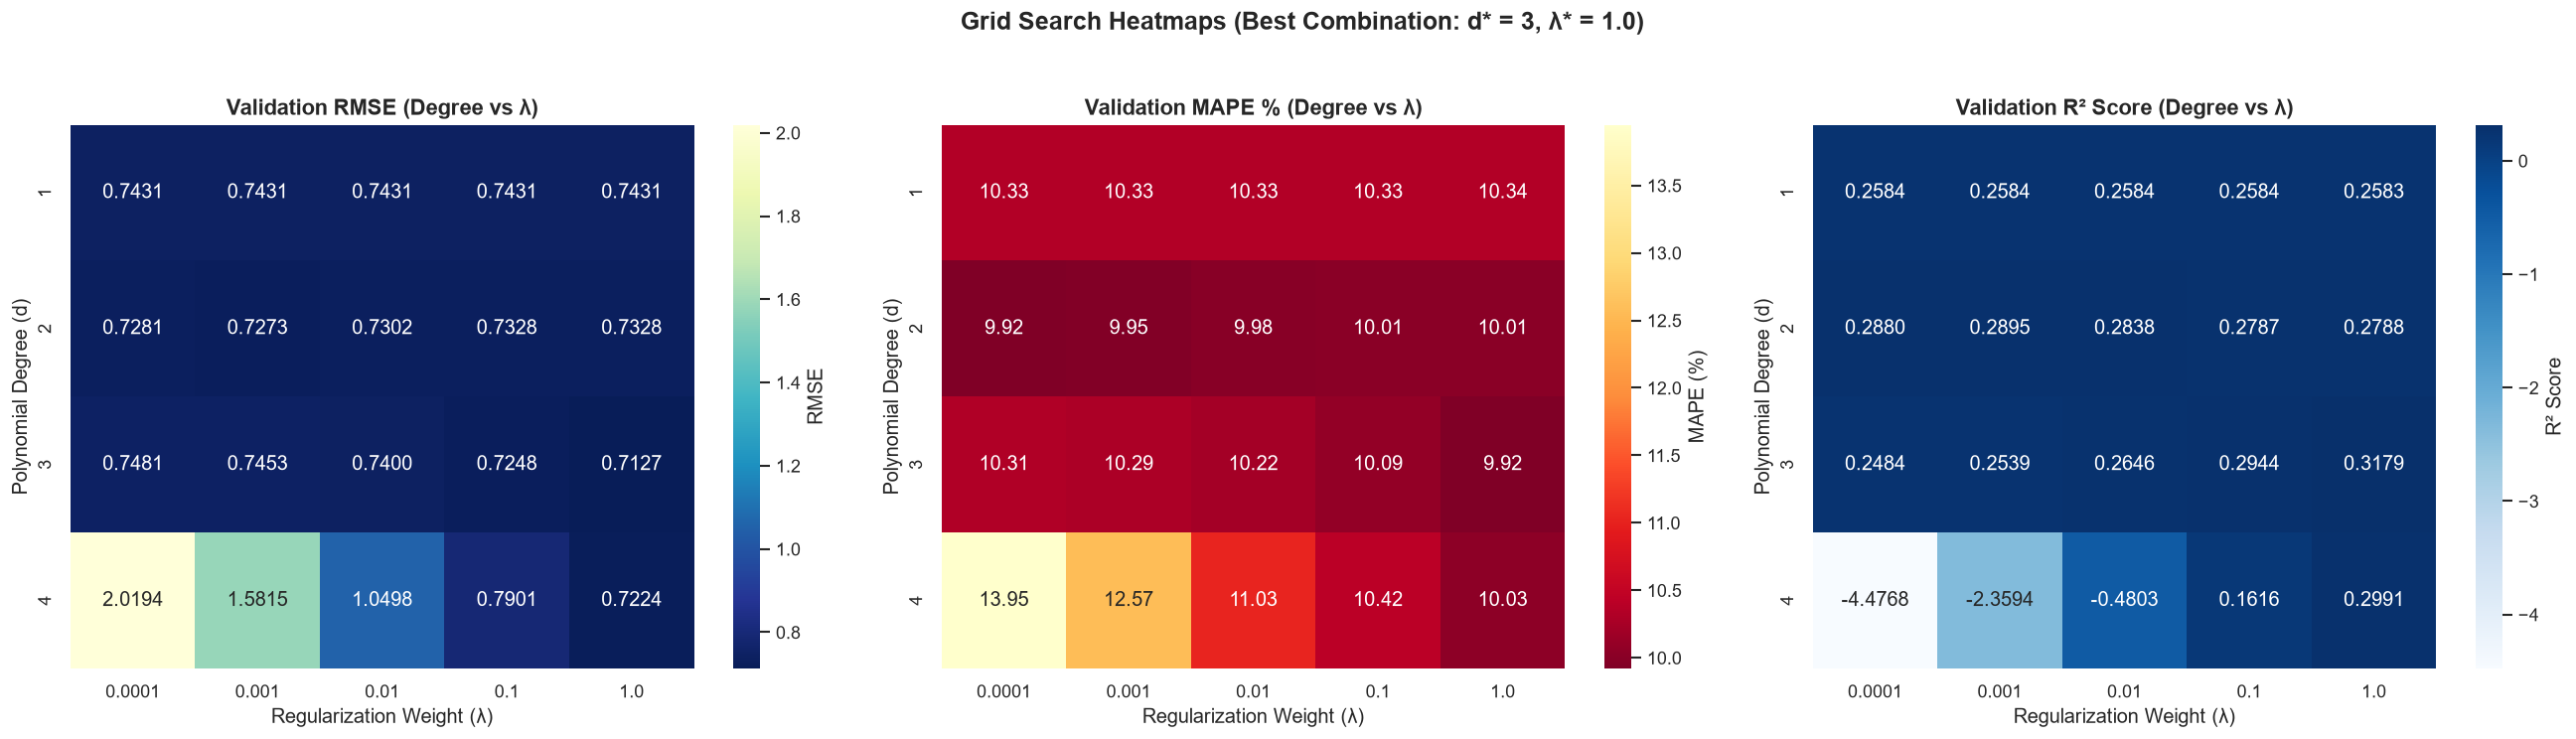

In [5]:
# Pivot tables for heatmaps
pivot_rmse = df_grid.pivot(index='Degree (d)', columns='Lambda (λ)', values='Val RMSE')
pivot_mape = df_grid.pivot(index='Degree (d)', columns='Lambda (λ)', values='Val MAPE (%)')
pivot_r2   = df_grid.pivot(index='Degree (d)', columns='Lambda (λ)', values='Val R2')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Heatmap 1: Validation RMSE (lower is better)
sns.heatmap(pivot_rmse, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[0], cbar_kws={'label': 'RMSE'})
axes[0].set_title("Validation RMSE (Degree vs λ)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Regularization Weight (λ)")
axes[0].set_ylabel("Polynomial Degree (d)")

# Heatmap 2: Validation MAPE (lower is better)
sns.heatmap(pivot_mape, annot=True, fmt=".2f", cmap="YlOrRd_r", ax=axes[1], cbar_kws={'label': 'MAPE (%)'})
axes[1].set_title("Validation MAPE % (Degree vs λ)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Regularization Weight (λ)")
axes[1].set_ylabel("Polynomial Degree (d)")

# Heatmap 3: Validation R2 (higher is better)
sns.heatmap(pivot_r2, annot=True, fmt=".4f", cmap="Blues", ax=axes[2], cbar_kws={'label': 'R² Score'})
axes[2].set_title("Validation R² Score (Degree vs λ)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Regularization Weight (λ)")
axes[2].set_ylabel("Polynomial Degree (d)")

plt.suptitle(f"Grid Search Heatmaps (Best Combination: d* = {best_degree}, λ* = {best_lambda})", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Task 6: Inference on the Unseen Test Set

Using the selected optimal hyperparameters ($d^*, \lambda^*$):
1. Train the final Ridge Regression model on the training set.
2. Evaluate on the **unseen Test Set**.
3. Report final performance comparison (RMSE, MAPE, $R^2$) across Training, Validation, and Test sets.
4. Plot **Actual vs. Predicted Wine Quality** scatter plot with ideal prediction line ($y=x$).

FINAL RIDGE REGRESSION EVALUATION (d* = 3, λ* = 1.0)
       Dataset Split  Samples   RMSE MAPE (%) R² Score
  Training Set (60%)     2938 0.6731    9.23%   0.4300
Validation Set (20%)      979 0.7127    9.92%   0.3179
      Test Set (20%)      981 0.7394    9.69%   0.3082


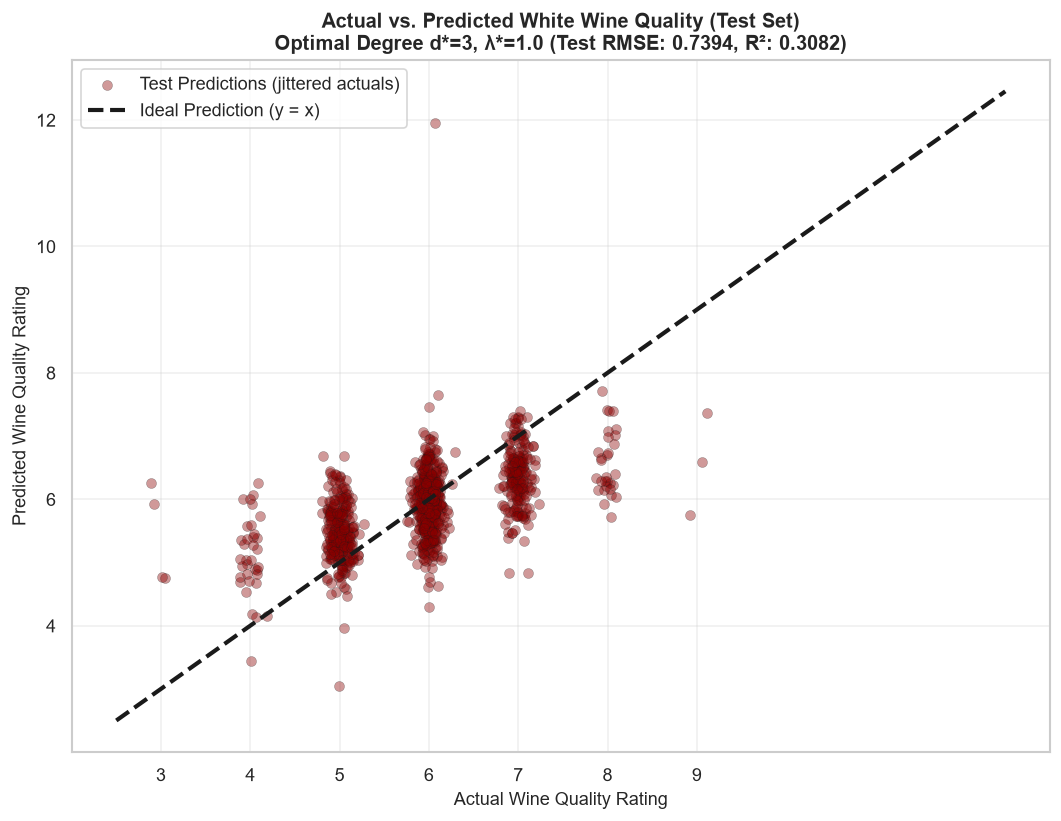

In [6]:
# 1. Prepare features for best polynomial degree
X_tr_b_best, X_va_b_best, X_te_b_best = prepare_polynomial_features(
    X_train, X_val, X_test, degree=best_degree
)

# 2. Train final model with best lambda
final_model = RidgeRegressionNormalEquation(l2_reg=best_lambda)
final_model.fit(X_tr_b_best, y_train)

# 3. Predict on all splits
y_tr_pred = final_model.predict(X_tr_b_best)
y_va_pred = final_model.predict(X_va_b_best)
y_te_pred = final_model.predict(X_te_b_best)

# Compute metrics
tr_rmse = compute_rmse(y_train, y_tr_pred)
va_rmse = compute_rmse(y_val, y_va_pred)
te_rmse = compute_rmse(y_test, y_te_pred)

tr_mape = compute_mape(y_train, y_tr_pred)
va_mape = compute_mape(y_val, y_va_pred)
te_mape = compute_mape(y_test, y_te_pred)

tr_r2 = compute_r2(y_train, y_tr_pred)
va_r2 = compute_r2(y_val, y_va_pred)
te_r2 = compute_r2(y_test, y_te_pred)

df_final_summary = pd.DataFrame([
    {'Dataset Split': 'Training Set (60%)', 'Samples': len(y_train), 'RMSE': f"{tr_rmse:.4f}", 'MAPE (%)': f"{tr_mape:.2f}%", 'R² Score': f"{tr_r2:.4f}"},
    {'Dataset Split': 'Validation Set (20%)', 'Samples': len(y_val), 'RMSE': f"{va_rmse:.4f}", 'MAPE (%)': f"{va_mape:.2f}%", 'R² Score': f"{va_r2:.4f}"},
    {'Dataset Split': 'Test Set (20%)', 'Samples': len(y_test), 'RMSE': f"{te_rmse:.4f}", 'MAPE (%)': f"{te_mape:.2f}%", 'R² Score': f"{te_r2:.4f}"}
])

print("=" * 75)
print(f"FINAL RIDGE REGRESSION EVALUATION (d* = {best_degree}, λ* = {best_lambda})")
print("=" * 75)
print(df_final_summary.to_string(index=False))
print("=" * 75)

# 4. Scatter Plot: Actual vs Predicted Wine Quality on Test Set
plt.figure(figsize=(9, 7))

# Add slight jitter for visual readability of discrete quality ratings (3 to 9)
jitter = np.random.normal(0, 0.08, size=len(y_test))
plt.scatter(y_test + jitter, y_te_pred, alpha=0.4, color='darkred', edgecolors='k', linewidths=0.3, label='Test Predictions (jittered actuals)')

# Reference ideal diagonal line y = x
min_val = min(y_test.min(), y_te_pred.min()) - 0.5
max_val = max(y_test.max(), y_te_pred.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2.5, label='Ideal Prediction (y = x)')

plt.title(f"Actual vs. Predicted White Wine Quality (Test Set)\nOptimal Degree d*={best_degree}, λ*={best_lambda} (Test RMSE: {te_rmse:.4f}, R²: {te_r2:.4f})", fontsize=12, fontweight='bold')
plt.xlabel("Actual Wine Quality Rating", fontsize=11)
plt.ylabel("Predicted Wine Quality Rating", fontsize=11)
plt.xticks(range(3, 10))
plt.legend()
plt.tight_layout()
plt.show()